In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device:{device}")

Using device:cuda


### Data pipeline

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

**Download MNIST (28×28 grayscale images, 60k train / 10k test)**

In [6]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.9MB/s]


***DataLoader***


*    DataLoader batches the data and shuffles it each epoch
*  batch_size=64 means we update weights after seeing 64 images.

* um_workers=2 uses 2 CPU threads to load data in parallel.



In [7]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

In [8]:
print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Image shape      : {train_dataset[0][0].shape}")

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])


***Defining the CNN architecturet***

"""
    A two-block CNN for MNIST digit classification.

    Architecture:
        Input: [B, 1, 28, 28]   (B = batch size)

        Conv Block 1:
            Conv2d(1→32, 3×3, padding=1) → [B, 32, 28, 28]
            ReLU
            MaxPool2d(2×2)               → [B, 32, 14, 14]

        Conv Block 2:
            Conv2d(32→64, 3×3, padding=1) → [B, 64, 14, 14]
            ReLU
            MaxPool2d(2×2)                → [B, 64, 7, 7]

        Flatten:  [B, 64, 7, 7] → [B, 64*7*7] = [B, 3136]

        FC Block:
            Linear(3136 → 128) → ReLU → Dropout(0.25)
            Linear(128 → 10)   → output logits (one per digit)
    """

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32,
                               kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,
                               kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes (digits 0-9)
        self.dropout = nn.Dropout(p=0.25)
    def forward(self, x):
        """
        Define how data flows through the network.
        x shape at each step is shown in the comment.
        """
        # Block 1: Conv → ReLU → Pool
        x = self.conv1(x)           # [B, 32, 28, 28]
        x = F.relu(x)               # [B, 32, 28, 28]  (negatives → 0)
        x = self.pool(x)            # [B, 32, 14, 14]

        # Block 2: Conv → ReLU → Pool
        x = self.conv2(x)           # [B, 64, 14, 14]
        x = F.relu(x)               # [B, 64, 14, 14]
        x = self.pool(x)            # [B, 64,  7,  7]

        # Flatten: convert 3D tensor to 1D per sample
        x = x.view(x.size(0), -1)  # [B, 3136]
        # x.size(0) = batch size, -1 = PyTorch infers the rest

        # Fully connected
        x = self.fc1(x)             # [B, 128]
        x = F.relu(x)               # [B, 128]
        x = self.dropout(x)         # [B, 128]  (some neurons zeroed)
        x = self.fc2(x)             # [B, 10]   (raw logits)

        # We return raw logits (not softmax) because
        # nn.CrossEntropyLoss applies log_softmax internally.
        return x



In [12]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable:,}")


Total parameters     : 421,642
Trainable parameters : 421,642


In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    One full pass through the training data.
    Returns average loss and accuracy for this epoch.
    """
    model.train()   # enables dropout and batch norm (if any)
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        # --- Forward pass ---
        optimizer.zero_grad()       # clear gradients from last step
        outputs = model(images)     # [B, 10] logits
        loss = criterion(outputs, labels)

        # --- Backward pass ---
        loss.backward()             # compute gradients (backprop)
        optimizer.step()            # update weights

        # --- Track metrics ---
        total_loss += loss.item()
        predicted = outputs.argmax(dim=1)   # class with highest logit
        correct  += (predicted == labels).sum().item()
        total    += labels.size(0)

        if batch_idx % 200 == 0:
            print(f"  Batch {batch_idx:4d}/{len(loader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


In [16]:
def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on validation/test data.
    Disables gradient tracking for speed and memory efficiency.
    """
    model.eval()    # disables dropout
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():   # no gradients needed for inference
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct  += (predicted == labels).sum().item()
            total    += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [18]:
NUM_EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}


print("""  Starting Training""")




for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                             criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, test_loader,
                                      criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  → Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  → Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.2f}%")

  Starting Training

Epoch 1/5
  Batch    0/938 | Loss: 2.2945
  Batch  200/938 | Loss: 0.2092
  Batch  400/938 | Loss: 0.0587
  Batch  600/938 | Loss: 0.1133
  Batch  800/938 | Loss: 0.0482
  → Train Loss: 0.1599 | Train Acc: 95.00%
  → Val   Loss: 0.0425   | Val   Acc: 98.50%

Epoch 2/5
  Batch    0/938 | Loss: 0.0150
  Batch  200/938 | Loss: 0.1291
  Batch  400/938 | Loss: 0.0045
  Batch  600/938 | Loss: 0.0176
  Batch  800/938 | Loss: 0.0130
  → Train Loss: 0.0567 | Train Acc: 98.29%
  → Val   Loss: 0.0300   | Val   Acc: 98.91%

Epoch 3/5
  Batch    0/938 | Loss: 0.0157
  Batch  200/938 | Loss: 0.0097
  Batch  400/938 | Loss: 0.0358
  Batch  600/938 | Loss: 0.0159
  Batch  800/938 | Loss: 0.0341
  → Train Loss: 0.0393 | Train Acc: 98.81%
  → Val   Loss: 0.0306   | Val   Acc: 98.97%

Epoch 4/5
  Batch    0/938 | Loss: 0.0623
  Batch  200/938 | Loss: 0.0780
  Batch  400/938 | Loss: 0.1140
  Batch  600/938 | Loss: 0.0186
  Batch  800/938 | Loss: 0.2089
  → Train Loss: 0.0315 | Train A

***Visualizing training curves***

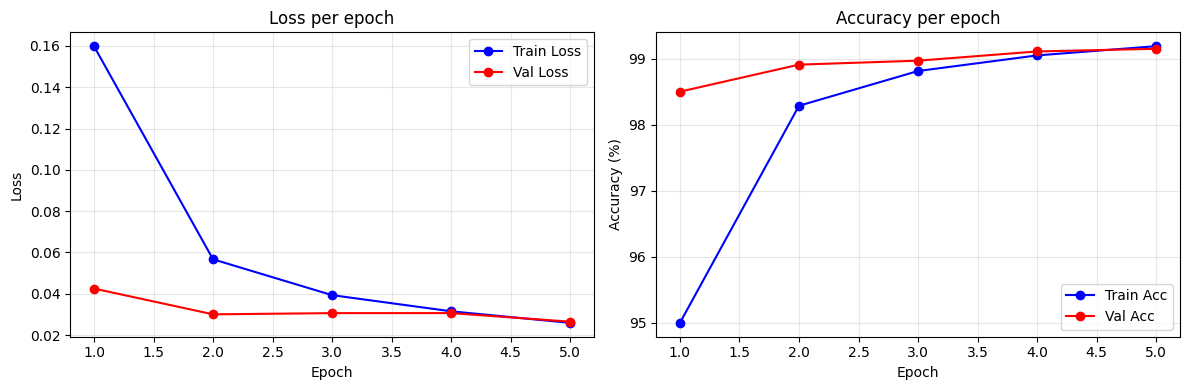

Training curves saved to training_curves.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["train_loss"], 'b-o', label='Train Loss')
axes[0].plot(epochs, history["val_loss"],   'r-o', label='Val Loss')
axes[0].set_title('Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["train_acc"], 'b-o', label='Train Acc')
axes[1].plot(epochs, history["val_acc"],   'r-o', label='Val Acc')
axes[1].set_title('Accuracy per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves saved to training_curves.png")

**Visualizing what the filters learned**

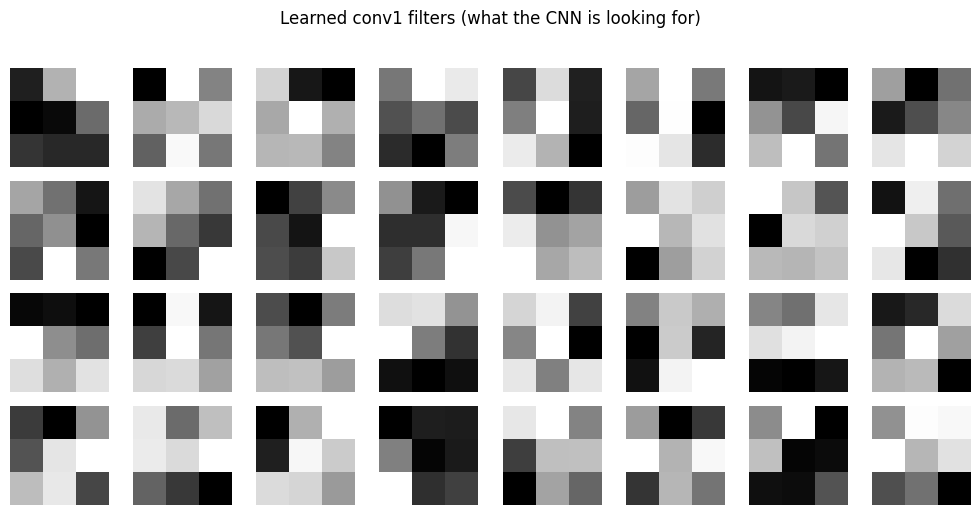

Filter visualizations saved to learned_filters.png


In [20]:
weights = model.conv1.weight.data.cpu()  # [32, 1, 3, 3]

fig, axes = plt.subplots(4, 8, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    # weights[i, 0] is the 3×3 filter for the i-th output channel
    w = weights[i, 0].numpy()
    # Normalize to [0,1] for display
    w = (w - w.min()) / (w.max() - w.min() + 1e-8)
    ax.imshow(w, cmap='gray')
    ax.axis('off')

plt.suptitle('Learned conv1 filters (what the CNN is looking for)', y=1.02)
plt.tight_layout()
plt.savefig('learned_filters.png', dpi=150)
plt.show()
print("Filter visualizations saved to learned_filters.png")